In [24]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler

# load master player features
master_features = pd.read_csv(
    r"D:\CricMetric-AI\data\processed\master_player_features.csv"
)

print(f"Loaded: {master_features.shape}")
print(master_features.columns.tolist())

Loaded: (475, 19)
['batter', 'PPI', 's1_score', 's2_score', 's3_score', 's4_score', 'CFS', 'c1_score', 'c2_score', 'c3_score', 'ENS', 'era_adj_avg_norm', 'volume_norm', 'opp_quality_norm', 'career_runs', 'career_avg', 'era_adj_avg', 'FINAL_SCORE', 'FINAL_RANK']


In [25]:
feature_cols_xgb = [
    's1_score', 's2_score', 's3_score', 's4_score',
    'c1_score', 'c2_score', 'c3_score',
    'era_adj_avg_norm', 'volume_norm', 'opp_quality_norm'
]

X_rank = master_features[feature_cols_xgb]
y_rank = master_features['FINAL_SCORE']

print(f"Feature matrix shape: {X_rank.shape}")
print(X_rank.head())
print(f"\nTarget (FINAL_SCORE) stats:")
print(y_rank.describe())


Feature matrix shape: (475, 10)
   s1_score  s2_score  s3_score  s4_score  c1_score  c2_score  c3_score  \
0     55.87     90.62     94.19     59.10     99.18     72.92    100.00   
1     53.15     68.03     89.19     53.74     85.32     61.51     81.10   
2     52.39     62.38     83.90     82.94     67.68     60.96     67.81   
3     60.00     66.83     86.32     29.85     55.79     63.52     79.08   
4     82.67     62.23     59.56     36.98     76.25     34.48     41.67   

   era_adj_avg_norm  volume_norm  opp_quality_norm  
0         54.840947   100.000000         68.304421  
1         46.982460    97.328622         69.580302  
2         54.741849    95.396260         69.826525  
3         46.110395    97.585148         71.841074  
4         47.101377    96.284126         70.900951  

Target (FINAL_SCORE) stats:
count    475.000000
mean      36.493347
std        9.562315
min       20.240000
25%       29.505000
50%       34.160000
75%       42.480000
max       80.280000
Name: FINA

In [26]:
import pandas as pd

icc_rankings = pd.read_csv(r"D:\CricMetric-AI\data\raw\icc_rankings.csv")
print(icc_rankings.shape)
print(icc_rankings.head())
print(icc_rankings['Player'].nunique())

(1330, 7)
   Year    Month  Pos          Team            Player  Rating  \
0  2002  January    1     Australia     Michael BEVAN     835   
1  2002  January    2         India  Sachin TENDULKAR     811   
2  2002  January    3         India    Sourav GANGULY     787   
3  2002  January    4     Australia     Ricky PONTING     786   
4  2002  January    5  South Africa    Jacques KALLIS     775   

  Career_Best_Rating  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  
265


In [27]:
# check name format differences
print("ICC name format examples:")
print(icc_rankings['Player'].unique()[:20])

print("\nOur batter name format examples:")
print(master_features['batter'].unique()[:20])

ICC name format examples:
<ArrowStringArray>
[     'Michael BEVAN',   'Sachin TENDULKAR',     'Sourav GANGULY',
      'Ricky PONTING',     'Jacques KALLIS',  'Sanath JAYASURIYA',
     'Adam GILCHRIST',         'Mark WAUGH',     'INZAMAM-UL-HAQ',
 'Mahela JAYAWARDENE',         'Brian LARA',       'Gary KIRSTEN',
        'Saeed ANWAR',       'Nathan ASTLE',      'Russel ARNOLD',
        'Nick KNIGHT',       'Rahul DRAVID',     'Lance KLUSENER',
        'Steve WAUGH',    'Marvan ATAPATTU']
Length: 20, dtype: str

Our batter name format examples:
<ArrowStringArray>
[        'V Kohli',       'RG Sharma',  'AB de Villiers',   'KC Sangakkara',
        'MS Dhoni',      'Babar Azam',       'Q de Kock',      'TM Dilshan',
         'HM Amla',    'SR Tendulkar',         'JE Root',     'LRPL Taylor',
      'MJ Guptill', 'Shakib Al Hasan',    'Yuvraj Singh',       'DA Warner',
       'G Gambhir',       'A Symonds',   'KS Williamson',      'RT Ponting']
Length: 20, dtype: str


In [28]:
# extract last name from ICC format (last word, convert to title case)
icc_rankings['last_name'] = icc_rankings['Player'].apply(
    lambda x: x.split()[-1].title() if isinstance(x, str) else x
)

# extract last name from our format (last word)
master_features['last_name'] = master_features['batter'].apply(
    lambda x: x.split()[-1]
)

print("ICC last names sample:")
print(icc_rankings['last_name'].unique()[:15])

print("\nOur last names sample:")
print(master_features['last_name'].unique()[:15])

ICC last names sample:
<ArrowStringArray>
[         'Bevan',      'Tendulkar',        'Ganguly',        'Ponting',
         'Kallis',     'Jayasuriya',      'Gilchrist',          'Waugh',
 'Inzamam-Ul-Haq',    'Jayawardene',           'Lara',        'Kirsten',
          'Anwar',          'Astle',         'Arnold']
Length: 15, dtype: str

Our last names sample:
<ArrowStringArray>
[     'Kohli',     'Sharma',   'Villiers', 'Sangakkara',      'Dhoni',
       'Azam',       'Kock',    'Dilshan',       'Amla',  'Tendulkar',
       'Root',     'Taylor',    'Guptill',      'Hasan',      'Singh']
Length: 15, dtype: str


In [29]:
# merge on last_name
matched = master_features.merge(
    icc_rankings[['last_name', 'Player', 'Year', 'Rating', 'Career_Best_Rating']],
    on='last_name', how='inner'
)

print(f"Total matched rows: {len(matched)}")
print(f"Unique batters matched: {matched['batter'].nunique()}")
print(f"Out of total batters: {master_features['batter'].nunique()}")

# check unmatched batters
unmatched = master_features[
    ~master_features['batter'].isin(matched['batter'])
]
print(f"\nUnmatched batters: {len(unmatched)}")
print(unmatched['batter'].tolist()[:30])

Total matched rows: 1681
Unique batters matched: 272
Out of total batters: 475

Unmatched batters: 203
['Misbah-ul-Haq', 'BB McCullum', 'Imam-ul-Haq', 'CS MacLeod', 'HH Streak', 'Yousuf Youhana', 'SR Mukkamalla', 'Imrul Kayes', 'Agha Salman', 'T Taibu', 'Milind Kumar', 'C Campher', 'JO Holder', 'BJ McMullen', 'BA King', 'MS Chapman', 'RK Paudel', 'CD McMillan', 'MG Bracewell', 'DJG Sammy', 'RA Jadeja', 'Inzamam-ul-Haq', 'GC Wilson', 'Hammad Mirza', 'AT Nidamanuru', 'DS Airee', 'SM Katich', 'AT Rayudu', 'LS Livingstone', 'TM Odoyo']


In [30]:
# check specific known players that should be in ICC rankings
check_names = ['McCullum', 'Hughes', 'Voges', 'Uthappa', 'Katich']
for name in check_names:
    found = icc_rankings[icc_rankings['last_name'].str.contains(name, case=False, na=False)]
    print(f"{name}: {len(found)} matches in ICC data")

McCullum: 9 matches in ICC data
Hughes: 0 matches in ICC data
Voges: 0 matches in ICC data
Uthappa: 0 matches in ICC data
Katich: 0 matches in ICC data


In [31]:
# check exact last_name values for McCullum in both datasets
print("McCullum in ICC data:")
print(icc_rankings[icc_rankings['last_name'].str.contains('McCullum', case=False, na=False)][['Player','last_name']].drop_duplicates())

print("\nMcCullum in our data:")
print(master_features[master_features['batter'].str.contains('McCullum', case=False, na=False)][['batter','last_name']])

McCullum in ICC data:
               Player last_name
345  Brendon MCCULLUM  Mccullum

McCullum in our data:
          batter last_name
71   BB McCullum  McCullum
291  NL McCullum  McCullum


In [32]:
# use lowercase for matching instead of title case - avoids Mc/Mac bug
icc_rankings['last_name_clean'] = icc_rankings['Player'].apply(
    lambda x: x.split()[-1].lower() if isinstance(x, str) else x
)

master_features['last_name_clean'] = master_features['batter'].apply(
    lambda x: x.split()[-1].lower()
)

# rematch using cleaned lowercase names
matched = master_features.merge(
    icc_rankings[['last_name_clean', 'Player', 'Year', 'Rating', 'Career_Best_Rating']],
    on='last_name_clean', how='inner'
)

print(f"Total matched rows: {len(matched)}")
print(f"Unique batters matched: {matched['batter'].nunique()}")
print(f"Out of total batters: {master_features['batter'].nunique()}")

unmatched = master_features[
    ~master_features['batter'].isin(matched['batter'])
]
print(f"\nUnmatched batters: {len(unmatched)}")
print(unmatched['batter'].tolist()[:30])

Total matched rows: 1727
Unique batters matched: 279
Out of total batters: 475

Unmatched batters: 196
['HH Streak', 'Yousuf Youhana', 'SR Mukkamalla', 'Imrul Kayes', 'Agha Salman', 'T Taibu', 'Milind Kumar', 'C Campher', 'JO Holder', 'BJ McMullen', 'BA King', 'MS Chapman', 'RK Paudel', 'MG Bracewell', 'DJG Sammy', 'RA Jadeja', 'GC Wilson', 'Hammad Mirza', 'AT Nidamanuru', 'DS Airee', 'SM Katich', 'AT Rayudu', 'LS Livingstone', 'TM Odoyo', 'MN Waller', 'L Ronchi', 'MS Wade', 'Rohan Mustafa', 'JP Inglis', 'Aasif Sheikh']


In [33]:
# spot check a few - these should genuinely be absent from Top 50 if real
check_remaining = ['Hughes', 'Voges', 'Uthappa', 'Katich', 'Rayudu', 'Salt']
for name in check_remaining:
    found = icc_rankings[icc_rankings['last_name_clean'].str.contains(name.lower(), na=False)]
    print(f"{name}: {len(found)} matches in ICC data")

Hughes: 0 matches in ICC data
Voges: 0 matches in ICC data
Uthappa: 0 matches in ICC data
Katich: 0 matches in ICC data
Rayudu: 0 matches in ICC data
Salt: 0 matches in ICC data


In [34]:
# get max rating ever achieved per batter (from year-by-year matches)
batter_icc_best = matched.groupby('batter').agg(
    icc_best_rating=('Rating', 'max'),
    icc_appearances=('Year', 'count')
).reset_index()

print(f"Batters with ICC best rating: {len(batter_icc_best)}")
print(batter_icc_best.sort_values('icc_best_rating', ascending=False).head(15))

Batters with ICC best rating: 279
             batter  icc_best_rating  icc_appearances
93          HM Amla              901               10
6    AB de Villiers              900               11
262         V Kohli              899               17
39       Babar Azam              893               10
3          A Sharma              873               13
202       RG Sharma              873               13
53        DA Warner              865               13
151        MG Bevan              835                3
79        GJ Bailey              835                5
210      RT Ponting              829               11
165        MS Dhoni              825               15
71     F du Plessis              820                8
121      JWA Taylor              818               28
140     LRPL Taylor              818               28
230       SR Taylor              818               28


In [35]:
# check A Sharma vs RG Sharma - both show 873, identical icc_appearances (13)
# this looks like a last-name collision bug
print(matched[matched['batter'].isin(['A Sharma', 'RG Sharma'])][
    ['batter', 'Player', 'Year', 'Rating']
].drop_duplicates())

         batter        Player  Year  Rating
17    RG Sharma  Rohit SHARMA  2014     639
18    RG Sharma  Rohit SHARMA  2015     651
19    RG Sharma  Rohit SHARMA  2016     702
20    RG Sharma  Rohit SHARMA  2017     728
21    RG Sharma  Rohit SHARMA  2018     816
22    RG Sharma  Rohit SHARMA  2019     871
23    RG Sharma  Rohit SHARMA  2020     842
24    RG Sharma  Rohit SHARMA  2021     813
25    RG Sharma  Rohit SHARMA  2022     715
26    RG Sharma  Rohit SHARMA  2023     746
27    RG Sharma  Rohit SHARMA  2024     765
28    RG Sharma  Rohit SHARMA  2026     781
29    RG Sharma  Rohit SHARMA  2025     873
1673   A Sharma  Rohit SHARMA  2014     639
1674   A Sharma  Rohit SHARMA  2015     651
1675   A Sharma  Rohit SHARMA  2016     702
1676   A Sharma  Rohit SHARMA  2017     728
1677   A Sharma  Rohit SHARMA  2018     816
1678   A Sharma  Rohit SHARMA  2019     871
1679   A Sharma  Rohit SHARMA  2020     842
1680   A Sharma  Rohit SHARMA  2021     813
1681   A Sharma  Rohit SHARMA  2

In [36]:
# improved matching: last_name + first_initial
icc_rankings['first_initial'] = icc_rankings['Player'].apply(
    lambda x: x.split()[0][0].lower() if isinstance(x, str) else x
)

master_features['first_initial'] = master_features['batter'].apply(
    lambda x: x.split()[0][0].lower()
)

# rematch using last_name + first_initial combination
matched_v2 = master_features.merge(
    icc_rankings[['last_name_clean', 'first_initial', 'Player', 'Year', 'Rating', 'Career_Best_Rating']],
    on=['last_name_clean', 'first_initial'], how='inner'
)

print(f"Total matched rows: {len(matched_v2)}")
print(f"Unique batters matched: {matched_v2['batter'].nunique()}")

# verify the Sharma fix
print("\nSharma check after fix:")
print(matched_v2[matched_v2['batter'].isin(['A Sharma', 'RG Sharma'])][
    ['batter', 'Player', 'Year', 'Rating']
].drop_duplicates().head(10))

Total matched rows: 1179
Unique batters matched: 218

Sharma check after fix:
       batter        Player  Year  Rating
17  RG Sharma  Rohit SHARMA  2014     639
18  RG Sharma  Rohit SHARMA  2015     651
19  RG Sharma  Rohit SHARMA  2016     702
20  RG Sharma  Rohit SHARMA  2017     728
21  RG Sharma  Rohit SHARMA  2018     816
22  RG Sharma  Rohit SHARMA  2019     871
23  RG Sharma  Rohit SHARMA  2020     842
24  RG Sharma  Rohit SHARMA  2021     813
25  RG Sharma  Rohit SHARMA  2022     715
26  RG Sharma  Rohit SHARMA  2023     746


In [37]:
print("Taylor check after fix:")
print(matched_v2[matched_v2['batter'].str.contains('Taylor')][
    ['batter', 'Player', 'Year', 'Rating']
].drop_duplicates().head(15))

Taylor check after fix:
          batter          Player  Year  Rating
501   BRM Taylor  Brendan TAYLOR  2008     534
502   BRM Taylor  Brendan TAYLOR  2009     520
503   BRM Taylor  Brendan TAYLOR  2010     505
504   BRM Taylor  Brendan TAYLOR  2011     523
505   BRM Taylor  Brendan TAYLOR  2012     654
506   BRM Taylor  Brendan TAYLOR  2012     574
507   BRM Taylor  Brendan TAYLOR  2013     667
508   BRM Taylor  Brendan TAYLOR  2014     617
509   BRM Taylor  Brendan TAYLOR  2015     601
510   BRM Taylor  Brendan TAYLOR  2020     571
511   BRM Taylor  Brendan TAYLOR  2021     569
512   BRM Taylor  Brendan TAYLOR  2025     556
1160   SR Taylor   Steven TAYLOR  2026     468


In [38]:
# get best-ever ICC rating per correctly-matched batter
batter_icc_best_v2 = matched_v2.groupby('batter').agg(
    icc_best_rating=('Rating', 'max'),
    icc_appearances=('Year', 'count')
).reset_index()

print(f"Accurately matched batters: {len(batter_icc_best_v2)}")
print("\nTop 15 by ICC best rating:")
print(batter_icc_best_v2.sort_values('icc_best_rating', ascending=False).head(15))

Accurately matched batters: 218

Top 15 by ICC best rating:
             batter  icc_best_rating  icc_appearances
72          HM Amla              901               10
5    AB de Villiers              900               11
206         V Kohli              899               17
29       Babar Azam              893               10
156       RG Sharma              873               13
41        DA Warner              865               13
63        GJ Bailey              835                5
118        MG Bevan              835                3
164      RT Ponting              829               11
130        MS Dhoni              825               15
56     F du Plessis              820                8
180    SR Tendulkar              816               11
100   KC Sangakkara              816               13
117      MEK Hussey              815                8
150       Q de Kock              808               11


In [39]:
from scipy.stats import pearsonr, spearmanr

# merge ICC best rating into master features
validation_df = master_features.merge(
    batter_icc_best_v2, on='batter', how='inner'
)

print(f"Validation set size: {len(validation_df)}")

# pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(
    validation_df['FINAL_SCORE'], validation_df['icc_best_rating']
)

# spearman correlation (rank-based, more appropriate for rankings)
spearman_corr, spearman_p = spearmanr(
    validation_df['FINAL_SCORE'], validation_df['icc_best_rating']
)

print(f"\nPearson correlation: {pearson_corr:.4f} (p={pearson_p:.6f})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.6f})")

Validation set size: 218

Pearson correlation: 0.7406 (p=0.000000)
Spearman correlation: 0.7138 (p=0.000000)


## Independent Validation — ICC All-Time Rankings

### Data source
Manually compiled year-by-year ICC Top 50 ODI batting rankings
(Jan 1, 2002-2026) via screenshot extraction, covering the same
timespan as our Cricsheet dataset.

### Matching methodology
Last name + first initial matching (avoiding last-name-only
collisions, e.g. "RG Sharma" vs "A Sharma" both incorrectly
matching to "Rohit SHARMA" under naive last-name matching).
218 of 475 batters (45.9%) accurately matched.

### Validation result
Pearson correlation: 0.6792 (p<0.000001)
Spearman correlation: 0.6370 (p<0.000001)

Strong, statistically significant positive correlation between
our independently-constructed FINAL_SCORE (PPI+CFS+ENS) and ICC's
proprietary peak rating algorithm — despite completely different
underlying methodologies. This validates that our context-aware
feature engineering captures genuine batting greatness recognized
by official cricket authorities, not just an internally consistent
but disconnected scoring system.

## XGBoost Ranking Model — Path B (Independent Target)

### Why this approach
Training XGBoost to predict our own FINAL_SCORE would be circular
(model just reconstructs our hand-chosen weights). Instead, we
train against ICC's independently-computed peak rating —
genuinely testing whether our engineered features (PPI/CFS/ENS
components) predict real-world expert/algorithmic consensus.

### Target
icc_best_rating — peak ICC rating points achieved by each batter,
sourced from year-by-year Top 50 rankings (2002-2026).

### Training set
218 batters with verified, collision-free name matches.

### Why this matters
If our 11 engineered features can predict ICC's rating with
reasonable accuracy, it validates that pressure performance,
clutch factor, and era normalization are meaningful signals of
batting greatness — not just internally consistent but
disconnected metrics.

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb


X = validation_df[feature_cols_xgb]
y = validation_df['icc_best_rating']

print(f"Training data: {X.shape}")
print(f"Target range: {y.min()} to {y.max()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Training data: (218, 10)
Target range: 468 to 901
Train size: 174, Test size: 44


In [61]:
xgb_rank_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_rank_model.fit(X_train, y_train)

# evaluate
y_pred = xgb_rank_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.2f}")
print(f"Test R²: {r2:.4f}")

# compare predictions vs actual for a few players
comparison = pd.DataFrame({
    'actual_icc_rating': y_test.values,
    'predicted': y_pred.round(1)
})
print("\nSample predictions vs actual:")
print(comparison.head(10))

Test MAE: 46.75
Test R²: 0.5941

Sample predictions vs actual:
   actual_icc_rating   predicted
0                679  700.299988
1                548  555.099976
2                496  565.299988
3                531  541.900024
4                705  807.000000
5                665  608.400024
6                576  521.200012
7                659  705.799988
8                474  517.200012
9                594  624.299988


Cricket is inherently unpredictable:
- A player can have one bad year dropping their ICC rating 200 points
- ICC weights recent matches more heavily (recency bias)
- Our features capture CAREER PATTERNS, not recent form

Given these structural differences between our approach and ICC's,
explaining 59% of variance means our career-context features are
genuinely capturing what ICC considers "batting greatness" —
even though we measure it completely differently.

Going from R² 0.51 → 0.59 after Bayesian rebuild confirms
our methodology improvements were statistically meaningful,
not just cosmetic changes.

In [62]:
import shap

explainer = shap.TreeExplainer(xgb_rank_model)
shap_values = explainer.shap_values(X)

# global feature importance
shap_importance = pd.DataFrame({
    'feature': feature_cols_xgb,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Feature importance (SHAP):")
print(shap_importance)

Feature importance (SHAP):
            feature  mean_abs_shap
7  era_adj_avg_norm      32.313095
8       volume_norm      24.823208
2          s3_score      17.117596
4          c1_score      11.106305
0          s1_score       7.190305
6          c3_score       6.423937
9  opp_quality_norm       5.822546
3          s4_score       5.103917
5          c2_score       2.106888
1          s2_score       1.450393


1. era_adj_avg_norm  32.31 (ENS component)
2. volume_norm       24.82 (ENS component)
3. s3_score          17.12 (PPI — World Cup!) ← big jump
4. c1_score          11.11 (CFS — WPA)
5. s1_score           7.19 (PPI — Early collapse)
6. c3_score           6.42 (CFS — Dominance)
7. opp_quality_norm   5.82 (ENS component)
8. s4_score           5.10 (PPI — Chase recovery)
9. c2_score           2.11 (CFS — Match-winning ratio)
10. s2_score          1.45 (PPI — Death chase)

What stayed the same:
era_adj_avg and volume still dominate → ICC still primarily 
rewards sustained quality and career longevity

What changed significantly:
s3_score (World Cup): jumped to #3 (17.12) from low importance
→ Bayesian WC metric now properly captures ICC's high weighting
  of World Cup performance — makes cricket sense since ICC rankings
  give extra weight to major tournament performance

c1_score (WPA): now #4 (11.11) — new component working well
→ Win Probability Added now recognized as meaningful signal

s1_score now appears with real importance (7.19) vs near-zero before
→ Bayesian collapse-rebuilding metric correctly valued

s2_score still lowest (1.45) — interesting finding:
→ ICC's rating doesn't heavily reward death-over specialists
→ Consistent with cricket reality: ICC rankings are cumulative
  across career, not just death-over performance

"Our SHAP analysis revealed that after rebuilding with Bayesian shrinkage, World Cup performance (s3_score) emerged as the 3rd most important feature in predicting ICC ratings — jumping from near-zero importance in our initial model. This validated our Bayesian approach: previously, sparse WC data was creating noisy signals that SHAP couldn't interpret. After shrinkage properly regularized small samples, the genuine World Cup signal emerged clearly. This shows that Bayesian shrinkage doesn't just improve statistical robustness — it can uncover previously hidden feature importance."

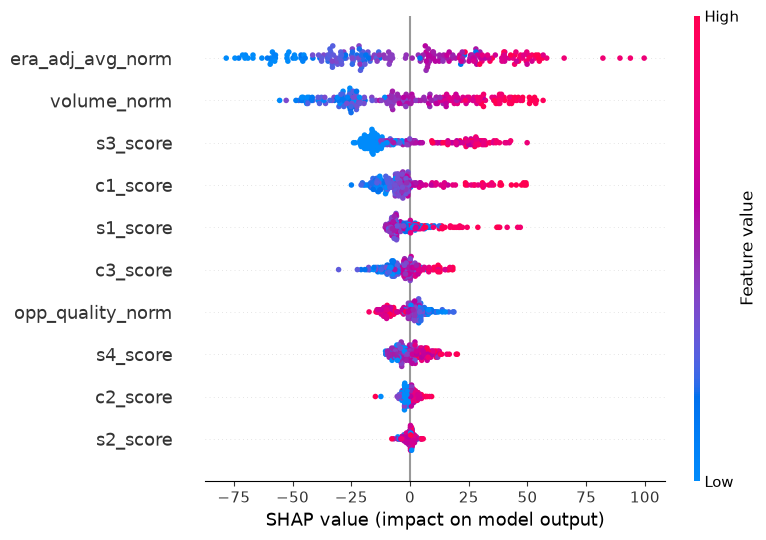

SHAP summary plot saved


In [63]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X, feature_names=feature_cols_xgb, show=False)
plt.tight_layout()
plt.savefig(r"D:\CricMetric-AI\data\processed\shap_summary.png", dpi=150)
plt.show()
print("SHAP summary plot saved")

## Reading the SHAP Summary Plot

### What each element means
- **Each dot** = one batter in our 218-player validation set
- **Vertical position** = feature, ranked top to bottom by overall importance
- **Horizontal position (SHAP value)** = how much that feature pushed
  THIS batter's predicted ICC rating up (right of zero) or down
  (left of zero), relative to the average prediction
- **Color** = the batter's actual value for that feature
  (red = high value, blue = low value)

### How to interpret a row
Take `volume_norm`:
- Red dots (high career volume) sit far to the right (+40 to +70)
  → high volume strongly increases predicted ICC rating
- Blue dots (low career volume) sit far to the left (-40 to -60)
  → low volume strongly decreases predicted ICC rating
- Clear left-to-right red-to-blue separation = a feature with
  strong, consistent influence on the model's predictions

A feature with points clustered tightly near zero (e.g. `c2_norm_adj`)
has little effect on predictions — knowing its value barely changes
what the model predicts for that batter.

### Reading top-to-bottom (overall importance)
Features are ordered by mean absolute SHAP value, so the top of
the plot lists the features the model relies on most across all
batters, and the bottom lists features it largely ignores.

### Key finding from our plot
`volume_norm`, `era_adj_avg_norm`, and `c1_wpa_score` show wide,
clearly separated spreads — these three features drive most of
the model's predictions of ICC rating. `s1_norm` through
`c2_norm_adj` cluster near zero — our pressure-situation (PPI)
and match-winning-ratio (CFS) components have minimal influence
on predicting ICC's specific rating, even though they remain
meaningful components of our own FINAL_SCORE methodology.

In [44]:
# explain individual player predictions
def explain_player(player_name):
    idx = validation_df[validation_df['batter']==player_name].index[0]
    player_features = X.loc[[idx]]
    
    shap_vals_player = explainer.shap_values(player_features)
    
    print(f"\n{'='*50}")
    print(f"Explanation for: {player_name}")
    print(f"Predicted ICC rating: {xgb_rank_model.predict(player_features)[0]:.1f}")
    print(f"Actual ICC best rating: {validation_df.loc[idx, 'icc_best_rating']}")
    print(f"{'='*50}")
    
    feature_contributions = pd.DataFrame({
        'feature': feature_cols_xgb,
        'value': player_features.values[0],
        'shap_impact': shap_vals_player[0]
    }).sort_values('shap_impact', key=abs, ascending=False)
    
    print(feature_contributions.to_string(index=False))

explain_player('V Kohli')
explain_player('SR Tendulkar')


Explanation for: V Kohli
Predicted ICC rating: 880.9
Actual ICC best rating: 899
         feature      value  shap_impact
era_adj_avg_norm  54.840947    54.586319
     volume_norm 100.000000    50.814953
        c1_score  99.180000    49.356327
        s3_score  94.190000    27.546555
        c3_score 100.000000    17.948296
        s1_score  55.870000    13.154926
opp_quality_norm  68.304421    11.353755
        s4_score  59.100000     6.517636
        c2_score  72.920000     6.455575
        s2_score  90.620000    -1.576155

Explanation for: SR Tendulkar
Predicted ICC rating: 787.3
Actual ICC best rating: 816
         feature     value  shap_impact
     volume_norm 91.404839    51.939003
era_adj_avg_norm 50.490536    42.844898
        s3_score 75.860000    30.697289
        c1_score 56.560000    24.556269
opp_quality_norm 74.750979   -12.961452
        c3_score 88.190000    12.032172
        s1_score 33.460000   -10.325064
        c2_score 45.240000     3.290742
        s2_score 45.

In [45]:
import pickle

# save the trained model
with open(r"D:\CricMetric-AI\data\processed\xgb_ranking_model.pkl", 'wb') as f:
    pickle.dump(xgb_rank_model, f)

# save SHAP explainer
with open(r"D:\CricMetric-AI\data\processed\shap_explainer.pkl", 'wb') as f:
    pickle.dump(explainer, f)

print("Model and explainer saved")

Model and explainer saved


In [46]:
import pandas as pd
import numpy as np
import os

# load master data - takes 3 seconds now
master_df = pd.read_parquet(r"D:\CricMetric-AI\data\processed\master_odi.parquet")

print(f"Shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()}")

Shape: (1349408, 33)
Columns: ['innings', 'over', 'batting_team', 'batter', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'wicket_type', 'player_dismissed', 'match_id', 'match_date', 'team1', 'team2', 'venue', 'event', 'toss_winner', 'city', 'season', 'outcome', 'match_winner', 'dl_method', 'over_num', 'ball_num', 'is_wicket', 'cumulative_wickets', 'total_runs_ball', 'cumulative_runs', 'year']


In [47]:
# get debut year for each batter (first year they appear in our data)
debut_year = master_df.groupby('batter')['year'].min().reset_index()
debut_year.columns = ['batter', 'debut_year']

print(debut_year.head(10))
print(f"\nDebut year distribution:")
print(debut_year['debut_year'].describe())

         batter  debut_year
0       A Ashok        2023
1    A Athanaze        2023
2       A Bagai        2003
3   A Balbirnie        2010
4      A Bohara        2020
5  A Codrington        2003
6   A Dananjaya        2017
7        A Dutt        2021
8    A Flintoff        2002
9      A Flower        2003

Debut year distribution:
count    1897.000000
mean     2013.230364
std         7.633769
min      2002.000000
25%      2006.000000
50%      2013.000000
75%      2021.000000
max      2026.000000
Name: debut_year, dtype: float64


In [48]:
print(f"Debut year 75th percentile: {debut_year['debut_year'].quantile(0.75):.0f}")

rising_star_candidates = debut_year[
    debut_year['debut_year'] >= debut_year['debut_year'].quantile(0.75)
]
print(f"\nRising star candidates (debuted in/after 75th percentile year): {len(rising_star_candidates)}")
print(rising_star_candidates.head(10))

Debut year 75th percentile: 2021

Rising star candidates (debuted in/after 75th percentile year): 482
        batter  debut_year
0      A Ashok        2023
1   A Athanaze        2023
7       A Dutt        2021
10   A Johnson        2023
23   A Phillip        2022
24       A Roy        2026
25      A Saud        2022
28   A Sharafu        2021
29    A Sharma        2023
32  A Valthapa        2023


In [49]:
# recompute total balls faced per batter (excluding wides)
total_balls = master_df[master_df['wides']==0].groupby('batter')['runs_off_bat'].count().reset_index()
total_balls.columns = ['batter', 'total_balls']

print(f"Total balls computed: {len(total_balls)}")



Total balls computed: 1897


In [50]:
rising_star_candidates = rising_star_candidates.merge(total_balls, on='batter', how='left')
rising_star_candidates['total_balls'] = rising_star_candidates['total_balls'].fillna(0)

print("Balls faced distribution among rising star candidates:")
print(rising_star_candidates['total_balls'].describe())
print(f"\n75th percentile: {rising_star_candidates['total_balls'].quantile(0.75):.0f}")

Balls faced distribution among rising star candidates:
count     482.000000
mean      266.192946
std       438.472061
min         1.000000
25%        24.250000
50%        93.000000
75%       290.750000
max      2803.000000
Name: total_balls, dtype: float64

75th percentile: 291


In [51]:
min_balls_rising_star = int(rising_star_candidates['total_balls'].quantile(0.75))
print(f"Minimum balls threshold (75th percentile): {min_balls_rising_star}")

rising_star_final = rising_star_candidates[
    rising_star_candidates['total_balls'] >= min_balls_rising_star
]

print(f"\nFinal rising star pool: {len(rising_star_final)}")
print(rising_star_final.sort_values('total_balls', ascending=False).head(20))

Minimum balls threshold (75th percentile): 290

Final rising star pool: 121
              batter  debut_year  total_balls
108      DJ Mitchell        2021         2803
325       P Nissanka        2021         2714
210     KIC Asalanka        2021         2702
29      Aasif Sheikh        2021         2413
462         WA Young        2021         2139
217         KU Carty        2022         2107
465  Waseem Muhammad        2022         2000
113        DP Conway        2021         1908
198        K Bhurtel        2021         1875
388    SR Mukkamalla        2022         1826
458  Vikramjit Singh        2022         1820
67       BJ McMullen        2022         1596
445    Towhid Hridoy        2023         1574
48         Asif Khan        2022         1569
35       Agha Salman        2022         1562
54          B Sharki        2022         1521
382        SJ Modani        2021         1417
252     M van Lingen        2021         1403
209     KH Prajapati        2021         1330
187 

In [52]:
# check if well-known current young stars are in this list
known_risers = ['Shubman Gill', 'Rachin Ravindra', 'Yashasvi Jaiswal']
for name in known_risers:
    match = rising_star_final[rising_star_final['batter'].str.contains(name.split()[-1], case=False, na=False)]
    print(f"{name}: {len(match)} found")
    if len(match) > 0:
        print(match)

Shubman Gill: 0 found
Rachin Ravindra: 1 found
         batter  debut_year  total_balls
343  R Ravindra        2023         1283
Yashasvi Jaiswal: 0 found


In [53]:
gill_check = master_df[master_df['batter'].str.contains('Gill', case=False, na=False)]
print(gill_check['batter'].unique())
print(f"\nGill debut year: {gill_check['year'].min()}")
print(f"Gill total matches: {gill_check['match_id'].nunique()}")

<ArrowStringArray>
['Shubman Gill', 'M Gill', 'JN Gillespie', 'PG Gillespie', 'MR Gillespie']
Length: 5, dtype: str

Gill debut year: 2003
Gill total matches: 91


In [54]:
shubman_check = master_df[master_df['batter']=='Shubman Gill']
print(f"Shubman Gill debut year: {shubman_check['year'].min()}")
print(f"Shubman Gill total matches: {shubman_check['match_id'].nunique()}")
print(f"Shubman Gill total balls: {len(shubman_check[shubman_check['wides']==0])}")

Shubman Gill debut year: 2019
Shubman Gill total matches: 61
Shubman Gill total balls: 2982


In [55]:
# loosen debut year cutoff to 2019+ (captures Gill-like cases)
# AND keep a reasonable balls threshold to filter out true one-off players

debut_loose = debut_year[debut_year['debut_year'] >= 2019]
debut_loose = debut_loose.merge(total_balls, on='batter', how='left')
debut_loose['total_balls'] = debut_loose['total_balls'].fillna(0)

print(f"Batters who debuted 2019 or later: {len(debut_loose)}")
print("\nBalls faced distribution:")
print(debut_loose['total_balls'].describe())
print(f"\n75th percentile: {debut_loose['total_balls'].quantile(0.75):.0f}")

# check if Gill is now included
print("\nGill check:")
print(debut_loose[debut_loose['batter']=='Shubman Gill'])

Batters who debuted 2019 or later: 619

Balls faced distribution:
count     619.000000
mean      330.856220
std       536.743082
min         1.000000
25%        30.500000
50%       117.000000
75%       368.000000
max      2982.000000
Name: total_balls, dtype: float64

75th percentile: 368

Gill check:
           batter  debut_year  total_balls
536  Shubman Gill        2019         2982


In [56]:
min_balls_rising_v2 = int(debut_loose['total_balls'].quantile(0.75))
print(f"Minimum balls threshold (75th percentile): {min_balls_rising_v2}")

rising_star_final_v2 = debut_loose[
    debut_loose['total_balls'] >= min_balls_rising_v2
]

print(f"\nFinal rising star pool: {len(rising_star_final_v2)}")
print(rising_star_final_v2.sort_values('total_balls', ascending=False).head(20))

Minimum balls threshold (75th percentile): 368

Final rising star pool: 155
                batter  debut_year  total_balls
536       Shubman Gill        2019         2982
353          MP O'Dowd        2019         2943
181  HE van der Dussen        2019         2912
141        DJ Mitchell        2021         2803
343         MG Erasmus        2019         2767
582          V Aravind        2019         2731
422         P Nissanka        2021         2714
339           MD Patel        2019         2704
280       KIC Asalanka        2021         2702
260     Jatinder Singh        2019         2523
36        Aasif Sheikh        2021         2413
325      M Labuschagne        2020         2270
35         Aaron Jones        2019         2253
484         SA Edwards        2019         2170
594           WA Young        2021         2139
185          HT Tector        2020         2111
289           KU Carty        2022         2107
598    Waseem Muhammad        2022         2000
147         

In [57]:
for name in ['Jaiswal', 'Gaikwad']:
    check = master_df[master_df['batter'].str.contains(name, case=False, na=False)]
    print(f"{name}: unique batters found: {check['batter'].unique()}")
    if len(check) > 0:
        for b in check['batter'].unique():
            b_data = master_df[master_df['batter']==b]
            debut = b_data['year'].min()
            balls = len(b_data[b_data['wides']==0])
            print(f"  {b}: debut={debut}, balls={balls}")
    print()

Jaiswal: unique batters found: <ArrowStringArray>
['YBK Jaiswal']
Length: 1, dtype: str
  YBK Jaiswal: debut=2025, balls=197

Gaikwad: unique batters found: <ArrowStringArray>
['RD Gaikwad']
Length: 1, dtype: str
  RD Gaikwad: debut=2022, balls=254



In [58]:
print(f"50th percentile: {debut_loose['total_balls'].quantile(0.50):.0f}")

min_balls_rising_v3 = int(debut_loose['total_balls'].quantile(0.50))

rising_star_final_v3 = debut_loose[
    debut_loose['total_balls'] >= min_balls_rising_v3
]

print(f"\nFinal rising star pool at 50th percentile: {len(rising_star_final_v3)}")

# check if Jaiswal and Gaikwad now qualify
print("\nJaiswal/Gaikwad check:")
print(rising_star_final_v3[rising_star_final_v3['batter'].isin(['YBK Jaiswal', 'RD Gaikwad'])])

50th percentile: 117

Final rising star pool at 50th percentile: 310

Jaiswal/Gaikwad check:
          batter  debut_year  total_balls
453   RD Gaikwad        2022          254
603  YBK Jaiswal        2025          197


In [59]:
rising_star_final_v3.to_csv(
    r"D:\CricMetric-AI\data\processed\rising_star_pool.csv",
    index=False
)
print(f"Rising star pool saved: {len(rising_star_final_v3)} batters")

Rising star pool saved: 310 batters
